In [2]:
import os
os.environ['NUMBA_ENABLE_CUDASIM'] = '1'

In [31]:
from os.path import join
import sys

import numpy as np
from numba import cuda
from time import perf_counter

import matplotlib.pyplot as plt

In [66]:
def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

@cuda.jit
def jacobi_kernel(u, mask, out):
    i, j = cuda.grid(2)

    if mask[i,j]:
        out[i+1, j+1] = 0.25 * (u[i, j+1] + u[i+2, j+1] + u[i+1, j+2] + u[i+1, j])


def jacobi(u, interior_mask, max_iter, threads_per_grid=16):
    N = 512
    tpb = (threads_per_grid, threads_per_grid)
    bpg = (N // threads_per_grid, N // threads_per_grid)

    up = cuda.pinned_array((N+2,N+2), np.float64)
    maskp = cuda.pinned_array((N,N), np.bool)
    outp = cuda.pinned_array((N+2,N+2), np.float64)
    up[:, :] = np.copy(u)
    maskp[:, :] = interior_mask 
    outp[:,:] = np.copy(u)

    # Move data to gpu
    d_u = cuda.to_device(up)
    d_mask = cuda.to_device(maskp)
    d_out = cuda.to_device(outp)

    for i in range(max_iter):
        jacobi_kernel[bpg, tpb](d_u, d_mask, d_out)
        cuda.synchronize()
        d_u, d_out = d_out, d_u

    return d_u.copy_to_host()

In [64]:
def jacobi_original(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)

    for i in range(max_iter):
        # Compute average of left, right, up and down neighbors, see eq. (1)
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior

        if delta < atol:
            print(i)
            break
    return u

In [ ]:
u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
u_new_interior = u_new[interior_mask]
delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
u[1:-1, 1:-1][interior_mask] = u_new_interior

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(512, 512))

In [8]:
# Load data
LOAD_DIR = "../small_data/"
with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
    building_ids = f.read().splitlines()

In [20]:
N=1
building_ids = building_ids[:N]

In [21]:
# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype='bool')
for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

In [71]:
u_new = 0.25 * (u0[1:-1, :-2] + u0[1:-1, 2:] + u0[:-2, 1:-1] + u0[2:, 1:-1])

In [79]:
interior_mask.sum()

np.int64(55302)

In [74]:
interior_mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(512, 512))

In [77]:
x = np.array([1,2,3,4,5])
m = np.array([False, True, False, False, False])

x[m]

array([2])

In [72]:
u_new[interior_mask]
# delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
# u[1:-1, 1:-1][interior_mask] = u_new_interior

array([2.5 , 2.5 , 2.5 , ..., 2.5 , 1.25, 2.5 ], shape=(55302,))

In [22]:
# Run jacobi iterations for each floor plan
MAX_ITER = 20_000
ABS_TOL = 1e-4

In [53]:
interior_mask.shape

(512, 512)

In [69]:
# all_u = np.empty_like(all_u0)
# for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
#     u = jacobi(u0, interior_mask, MAX_ITER, 16)
#     all_u[i] = u

u = jacobi(u0, interior_mask, 10, 16)

In [44]:
u.sum()

np.float64(556978.0898816762)

In [45]:
u

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(514, 514))

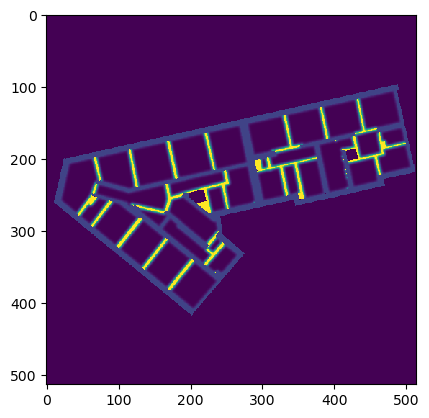

In [70]:
plt.imshow(u, interpolation='none')

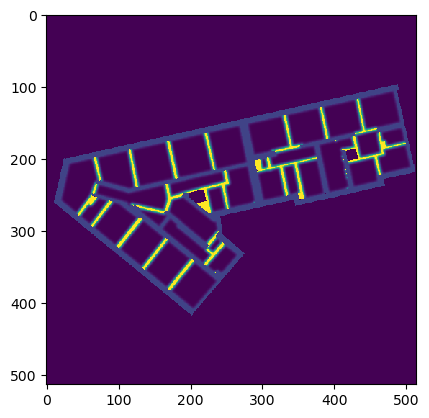

In [85]:
plt.imshow(u_o, interpolation='none')

In [83]:
# all_u_o = np.empty_like(all_u0)
# for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
#     u_o = jacobi_original(u0, interior_mask, MAX_ITER, ABS_TOL)
#     all_u_o[i] = u_o

u_o = jacobi_original(u0, interior_mask, 10, ABS_TOL)

In [29]:
u_o.sum()

np.float64(943030.3596602115)

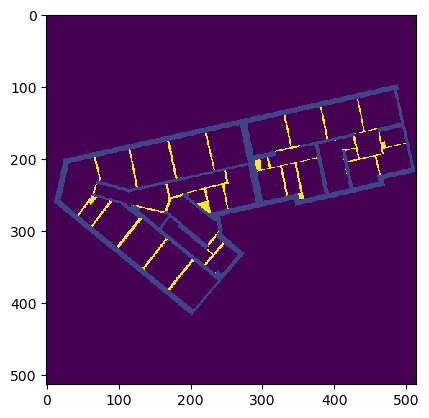

In [82]:
plt.imshow(u0, interpolation='none')

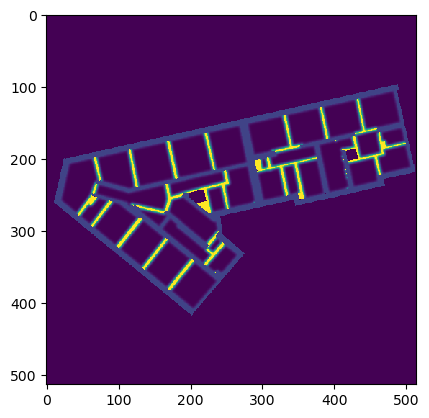

In [84]:
plt.imshow(u_o, interpolation='none')

In [ ]:

# Print summary statistics in CSV format
stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
print('building_id, ' + ', '.join(stat_keys))  # CSV header
for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
    stats = summary_stats(u, interior_mask)
    print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))